<a href="https://colab.research.google.com/github/MehrdadJalali-AI/Statistics-and-Machine-Learning/blob/main/InClass/NN_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparation Notebook: Neural Networks (Before Exercise)

This notebook prepares you for the **Neural Network exercise**.

✔ Step-by-step
✔ Simple and readable code
✔ Clear explanations before each step
✔ Focus on *how* to build and evaluate a NN

⚠️ This notebook does **NOT** decide which model is best.
You will do that in the exercise.

## 1. Import Required Libraries

**Why?**
- `numpy`, `pandas`: data handling
- `matplotlib`: visualization
- `sklearn`: dataset, split, metrics
- `tensorflow.keras`: neural networks


# **Common Layer Types in tensorflow.keras.layers**

**1. Fully Connected Layer**

Dense
Used in classic feedforward neural networks (MLP). Each neuron is connected to all neurons in the previous layer.

**2. Convolutional Layers**

Conv1D – for time series and sequential data

Conv2D – for images

Conv3D – for videos and 3D data
Used to learn local patterns such as edges and textures.

**3. Pooling Layers**

MaxPooling1D, MaxPooling2D, MaxPooling3D

AveragePooling1D, AveragePooling2D, AveragePooling3D
Reduce spatial dimensions and computation cost.

**4. Reshaping Layers**

Flatten – converts multi-dimensional input into a 1D vector

Reshape – reshapes data into a specified form
Commonly used between CNN and Dense layers.

**5. Recurrent Layers**

SimpleRNN

LSTM

GRU
Designed for sequential data and time-dependent patterns.

**6. Embedding Layer**

Embedding
Maps categorical values or words to dense vector representations (used in NLP).

**7. Normalization Layers**

BatchNormalization

LayerNormalization
Stabilize and speed up training.

**8. Regularization Layers**

Dropout
Randomly disables neurons during training to reduce overfitting.

**9. Activation Layers**

Activation

ReLU, LeakyReLU
Apply non-linear activation functions.

**10. Output / Probability Layers**

Softmax
Used in multi-class classification to output probabilities.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## 2. Load an Example Dataset (Classification)

**Why this dataset?**
- Small and clean
- Suitable for a Feedforward Neural Network (FNN)

You may replace this dataset in the exercise.

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
X.shape

(569, 30)

## 3. Train / Test Split

**Why?**
- Train data: learning
- Test data: evaluation on unseen samples

**Key parameter:**
- `test_size=0.3`: 30% test data

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 4. Feature Scaling

**Why scaling is important for Neural Networks?**
- Neural networks use gradients
- Different feature scales slow down learning

**StandardScaler:**
- Mean = 0
- Standard deviation = 1

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Build a Simple Feedforward Neural Network (FNN)

**Architecture:**
- Input layer → number of features
- Hidden layer with ReLU activation
- Output layer with Sigmoid (binary classification)

**Important parameters:**
- `Dense(units)`: number of neurons
- `activation`: non-linearity

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

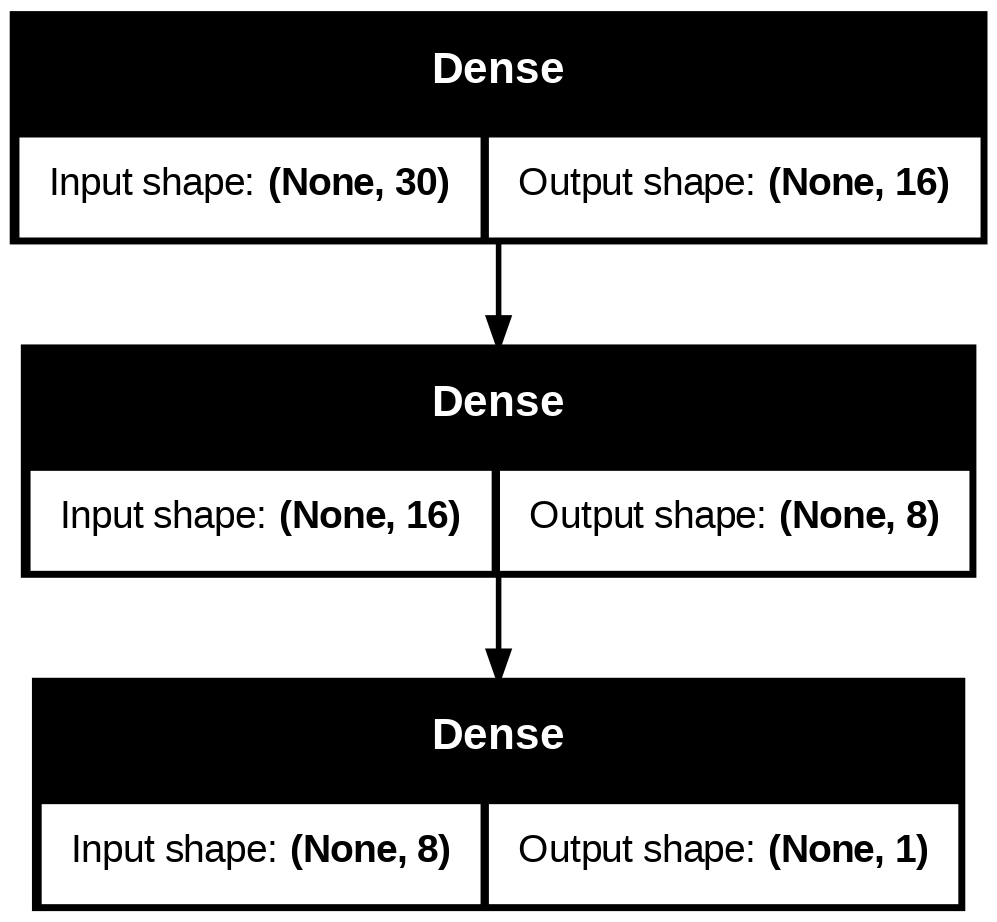

In [5]:
import tensorflow as tf

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))
#Each of the 16 neurons receives all 30 inputs
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()
tf.keras.utils.plot_model(model, to_file='model_big.png', show_shapes=True)

## 6. Compile the Model

**Why compile?**
- Defines how the model learns (seting some rules)

**Important parameters:**
- `optimizer='adam'`: Adam (Adaptive Moment Estimation) is an optimizer that updates model weights automatically.
It changes how fast each weight learns based on past errors, helping the model learn faster and more stably.

- `loss='binary_crossentropy'`: for binary classification
- `metrics=['accuracy']`: track accuracy during training

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 7. Train the Neural Network

**Key parameters:**
- `epochs`: number of training iterations
- `batch_size`: samples per update
- `validation_split`: part of training data for validation

⚠️ Values here are small for demonstration.

In [18]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,

)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5237 - loss: 1.0088 - val_accuracy: 0.6500 - val_loss: 0.7523
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5921 - loss: 0.7310 - val_accuracy: 0.7375 - val_loss: 0.5836
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6625 - loss: 0.6018 - val_accuracy: 0.8250 - val_loss: 0.4777
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8243 - loss: 0.4872 - val_accuracy: 0.8625 - val_loss: 0.4065
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8289 - loss: 0.4508 - val_accuracy: 0.9000 - val_loss: 0.3489
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8963 - loss: 0.3797 - val_accuracy: 0.9250 - val_loss: 0.3021
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8819 - loss: 0.3488 - val_accuracy: 0.9375 - val_loss: 0.2666
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8851 - loss: 0.3050 - val_accuracy: 0.9625 - v

## 8. Make Predictions

**Why thresholding?**
- Model outputs probabilities
- We convert them to class labels (0 or 1)

In [19]:
y_prob = model.predict(X_test_scaled)

y_pred = (y_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


## 9. Evaluation Metrics (Classification)

We evaluate the model using:
- Accuracy
- Precision
- Recall
- F1-score

These metrics match the exercise requirements.

In [20]:
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-score :', f1_score(y_test, y_pred))

Accuracy : 0.9766081871345029
Precision: 0.9814814814814815
Recall   : 0.9814814814814815
F1-score : 0.9814814814814815
